***** RED NEURONAL CON ENTRENAMIENTO SIMPLE **** 

DATASET
Datos de entrenamiento: (400, 2)
Datos de prueba: (100, 2)


 * Primer entrenamiento: Funcion de activacion SIGMOID *

Pesos iniciales entre entrada X1 ──► capas ocultas (4):
[ 0.24669165  0.48270399  0.09808377 -0.30094361]
Pesos iniciales entre entrada X2 ──► capas ocultas (4):
[ 0.31564564 -0.77830799 -0.54764173  0.36648759]

Pesos iniciales entre capas ocultas (4) ──► salida:
[ [-0.67862762] [-0.09454073] [-0.07175617] [-0.264331] ]

 Evolucion del Loss a lo largo de iteraciones/épocas:
 Epoca 0 - Perdida: 0.7240
 Epoca 200 - Perdida: 0.4716
 Epoca 400 - Perdida: 0.3548
 Epoca 600 - Perdida: 0.3166
 Epoca 800 - Perdida: 0.3002
 Epoca 1000 - Perdida: 0.2926
 Epoca 1200 - Perdida: 0.2891
 Epoca 1400 - Perdida: 0.2873
 Epoca 1600 - Perdida: 0.2865
 Epoca 1800 - Perdida: 0.2860
 Epoca 1999 - Perdida: 0.2857

Pesos finales entre entrada X1 ──► capas ocultas (4):
[-0.53394899  0.57598924  0.51273409 -0.58541738]
Pesos finales en

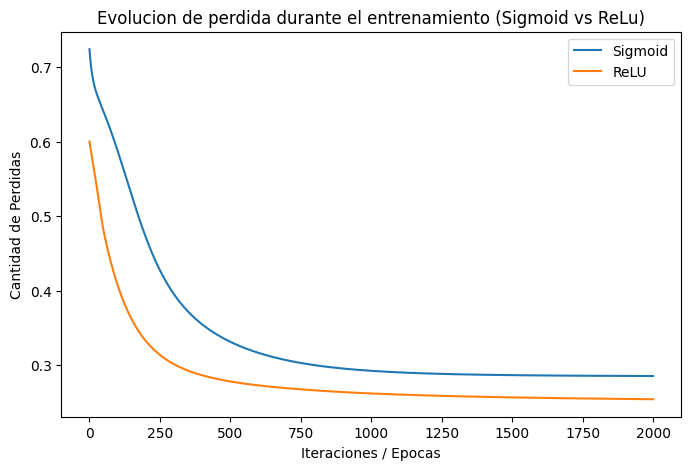

In [26]:
# Importacion de librerias necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


print("***** RED NEURONAL CON ENTRENAMIENTO SIMPLE **** \n")

# Creacion del Dataset de datos
np.random.seed(42)
datos_entrada, etiquetas = make_moons(n_samples=500, noise=0.2) #500 datos iniciales
etiquetas = etiquetas.reshape(-1,1) #Si es dato de entrenamiento o prueba

datos_entrenamiento, datos_prueba, etiquetas_entrenamiento, etiquetas_prueba = train_test_split(
    datos_entrada, etiquetas, test_size=0.2, random_state=42
)

print("DATASET")
print("Datos de entrenamiento:", datos_entrenamiento.shape) #Resultado total cantidad datos para entrenamiento
print("Datos de prueba:", datos_prueba.shape) #Resultado total cantidad datos para pruebas


# Funciones de activacion (Sigmoid y ReLU)
def sigmoid(x):
    return 1/(1+np.exp(-x))

def derivada_sigmoid(x):
    s = sigmoid(x)
    return s*(1-s)

def relu(x):
    return np.maximum(0,x)

def derivada_relu(x):
    return (x>0).astype(float)


# Funcion Inicializar parametros
def inicializar_parametros():
    pesos_capa_oculta = np.random.randn(2,4)*0.5  #Genera 2 entrada con 4 pesos aletorios para cada capa oculta por entrada
    sesgos_capa_oculta = np.zeros((1,4))

    pesos_capa_salida = np.random.randn(4,1)*0.5  #Genera 4 pesos aletorios para cada capa oculta por salida
    sesgos_capa_salida = np.zeros((1,1))

    return pesos_capa_oculta, sesgos_capa_oculta, pesos_capa_salida, sesgos_capa_salida


#Funcion Feedforward (Propagacion hacia adelante)
def propagacion_adelante(datos_entrada, pesos_capa_oculta, sesgos_capa_oculta, pesos_capa_salida, sesgos_capa_salida, activacion):

    suma_capa_oculta = datos_entrada.dot(pesos_capa_oculta) + sesgos_capa_oculta   #Calculo de capas ocultas (x1*w1 + x2*w2) + sesgo

    #Aplicamos la funcion de activacion al calculo de la capa oculta de entrada
    if activacion == "sigmoid":
        activacion_capa_oculta = sigmoid(suma_capa_oculta) #h1 = sigmoid(suma_capa_oculta)
    else:
        activacion_capa_oculta = relu(suma_capa_oculta)

    suma_capa_salida = activacion_capa_oculta.dot(pesos_capa_salida) + sesgos_capa_salida  #Calculo de capas de salida (h1*w1 + h2*w2 + h3*w3 + h4*w4)
    salida_predicha = sigmoid(suma_capa_salida)   #ŷ = sigmoid(suma_capa_salida) Prediccion

    return suma_capa_oculta, activacion_capa_oculta, suma_capa_salida, salida_predicha


#Funcion Calculo de perdida - Loss (realidad vs predicción)
def calcular_perdida(etiquetas_reales, salida_predicha):

    numero_muestras = etiquetas_reales.shape[0]

    perdida = -(1/numero_muestras)*np.sum(
        etiquetas_reales*np.log(salida_predicha+1e-8) +
        (1-etiquetas_reales)*np.log(1-salida_predicha+1e-8)
    )   #Obtener porcentaje de perdida

    return perdida


#Funcion Backpropagation (Propagación del error hacia atrás)
def retropropagacion(datos_entrada, etiquetas_reales, suma_capa_oculta, activacion_capa_oculta, salida_predicha, pesos_capa_salida, activacion):

    numero_muestras = datos_entrada.shape[0]

    error_salida = salida_predicha - etiquetas_reales   #error = predicción - valor_real

    #Cada peso recibe un gradiente que indica cuánto debe cambiar
    gradiente_pesos_salida = (1/numero_muestras)*activacion_capa_oculta.T.dot(error_salida)
    gradiente_sesgos_salida = (1/numero_muestras)*np.sum(error_salida,axis=0,keepdims=True)
    error_capa_oculta = error_salida.dot(pesos_capa_salida.T)

    if activacion=="sigmoid":
        gradiente_suma_oculta = error_capa_oculta*derivada_sigmoid(suma_capa_oculta)
    else:
        gradiente_suma_oculta = error_capa_oculta*derivada_relu(suma_capa_oculta)

    gradiente_pesos_oculta = (1/numero_muestras)*datos_entrada.T.dot(gradiente_suma_oculta)
    gradiente_sesgos_oculta = (1/numero_muestras)*np.sum(gradiente_suma_oculta,axis=0,keepdims=True)

    return gradiente_pesos_oculta, gradiente_sesgos_oculta, gradiente_pesos_salida, gradiente_sesgos_salida


# Funcion de Entrenamiento de Red Neuronal con 2000 epocas por defecto
def entrenar_red(datos_entrenamiento, etiquetas_entrenamiento, activacion, epocas=2000, tasa_aprendizaje=0.1):

    #Obtenemos parametros de entrada (inicializar pesos y sesgo)
    pesos_capa_oculta, sesgos_capa_oculta, pesos_capa_salida, sesgos_capa_salida = inicializar_parametros()

    print("\nPesos iniciales entre entrada X1 ──► capas ocultas (4):")
    print(pesos_capa_oculta[0])
    print("Pesos iniciales entre entrada X2 ──► capas ocultas (4):")
    print(pesos_capa_oculta[1])
    print("\nPesos iniciales entre capas ocultas (4) ──► salida:")
    print(f"[ {pesos_capa_salida[0]} {pesos_capa_salida[1]} {pesos_capa_salida[2]} {pesos_capa_salida[3]} ]")

    historial_perdida = []
    print("\n Evolucion del Loss a lo largo de iteraciones/épocas:")

    #Iteramos epoca por epoca (2000 en total)
    for epoca in range(epocas):

        #Forward Pass - Propagación hacia adelante para calculan las salidas de la red neuronal
        suma_capa_oculta, activacion_capa_oculta, suma_capa_salida, salida_predicha = propagacion_adelante(
            datos_entrenamiento, pesos_capa_oculta, sesgos_capa_oculta, pesos_capa_salida, sesgos_capa_salida, activacion
        )

        #Cálculo de la pérdida (Loss)
        perdida = calcular_perdida(etiquetas_entrenamiento, salida_predicha)

        #Backpropagation - Retropropagación del error para ajustar los pesos de la red neuronal y minimizar el error de predicción
        gradiente_pesos_oculta, gradiente_sesgos_oculta, gradiente_pesos_salida, gradiente_sesgos_salida = retropropagacion(
            datos_entrenamiento, etiquetas_entrenamiento, suma_capa_oculta, activacion_capa_oculta, salida_predicha, pesos_capa_salida, activacion
        )

        #Ajuste de los pesos (nuevo_peso = peso_actual − learning_rate × gradiente)
        pesos_capa_oculta -= tasa_aprendizaje*gradiente_pesos_oculta
        sesgos_capa_oculta -= tasa_aprendizaje*gradiente_sesgos_oculta
        pesos_capa_salida -= tasa_aprendizaje*gradiente_pesos_salida
        sesgos_capa_salida -= tasa_aprendizaje*gradiente_sesgos_salida

        historial_perdida.append(perdida)

        if (epoca % 200 == 0) or (epoca == 1999):
            print(f" Epoca {epoca} - Perdida: {perdida:.4f}")

    print("\nPesos finales entre entrada X1 ──► capas ocultas (4):")
    print(pesos_capa_oculta[0])
    print("Pesos finales entre entrada X2 ──► capas ocultas (4):")
    print(pesos_capa_oculta[1])
    print("\nPesos finales entre capas ocultas (4) ──► salida:")
    print(f"[ {pesos_capa_salida[0]} {pesos_capa_salida[1]} {pesos_capa_salida[2]} {pesos_capa_salida[3]} ]")

    return pesos_capa_oculta, sesgos_capa_oculta, pesos_capa_salida, sesgos_capa_salida, historial_perdida


#Primer aprendizaje con funcion de activacion Sigmoid
print("\n\n * Primer entrenamiento: Funcion de activacion SIGMOID *")
pesos_sig_oculta, sesgos_sig_oculta, pesos_sig_salida, sesgos_sig_salida, perdida_sigmoid = entrenar_red(
    datos_entrenamiento, etiquetas_entrenamiento, activacion="sigmoid"
) #Entrenamos la red indicando la funcion de activacion


#Segundo aprendizaje con funcion de activacion ReLu
print("\n\n * Segundo entrenamiento: Funcion de activacion RELU *")
pesos_relu_oculta, sesgos_relu_oculta, pesos_relu_salida, sesgos_relu_salida, perdida_relu = entrenar_red(
    datos_entrenamiento, etiquetas_entrenamiento, activacion="relu"
)


#Graficamos la comparativa entre funciones de activacion y su evolucion de perdida
print("\n\n")
plt.figure(figsize=(8,5))
plt.plot(perdida_sigmoid,label="Sigmoid")
plt.plot(perdida_relu,label="ReLU")
plt.title("Evolucion de perdida durante el entrenamiento (Sigmoid vs ReLu)")
plt.xlabel("Iteraciones / Epocas")
plt.ylabel("Cantidad de Perdidas")
plt.legend()
plt.show()



# **Red Neuronal con Aprendizaje Backpropagation y Funciones de Activación**

Para este algoritmo se agregaron dos entradas X1, X2, cuatro capas ocultas H1, H2, H3, H4 y una salida. Los datos de entrada y etiquetas se generan una unica vez desde un dataset de numpy.
Este modelo se empleo igual para las dos funciones de activacion y asi poder realizar una comparacion valida.

Dataset ──► Forward Pass ──► Predicción ──► Cálculo de error ──► Backpropagation ──► Ajuste de pesos ──► Repetir 2000 veces ──► Modelo entrenado

El gran análisis de este ejercicio es que la red neuronal logra reducir el error durante el entrenamiento, lo que indica que está aprendiendo. Esto es evidenciable en los resultados por cada Epoca el error disminuye progresivamente, demostrando que el algoritmo de backpropagation y descenso de gradiente funciona correctamente.

Tambien es evidenciable como los pesos iniciales son muy diferentes a los finales, demostrando que el algoritmo se adapta para optimizar la salida.

En cuanto a la comparación de las funciones de activación Sigmoid y ReLu se puede mencionar que la eleccion de una función de activación influye en el desempeño del modelo. Aquí se puede observar que ReLU suele presentar una convergencia más rápida y con mayor precisión que Sigmoid.